# Breast Cancer Wisconsin (Diagnostic) - Supervised Learning Assignment
**Dataset Source:** UCI Machine Learning Repository (Breast Cancer Wisconsin Diagnostic Dataset), accessed via `sklearn.datasets`.

**Problem Type:** Binary Classification (Malignant vs Benign)

This notebook covers dataset understanding, preprocessing, EDA, model building with six supervised algorithms, evaluation, and comparison.

## Part 1: Dataset Understanding

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0 = malignant, 1 = benign

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Data types:")
print(df.dtypes.value_counts())
print()
print("Target variable distribution:")
print(df["target"].value_counts().rename({0: "Malignant", 1: "Benign"}))
print()
print("Problem type: Binary Classification")


Data types:
float64    30
int64       1
Name: count, dtype: int64

Target variable distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64

Problem type: Binary Classification


## Part 2: Data Preprocessing

In [4]:
print("Missing values per column (total):", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()


Missing values per column (total): 0
Duplicate rows: 0


In [5]:
# Outlier detection using IQR method
Q1 = df.drop(columns="target").quantile(0.25)
Q3 = df.drop(columns="target").quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((df.drop(columns="target") < (Q1 - 1.5 * IQR)) |
                (df.drop(columns="target") > (Q3 + 1.5 * IQR)))
print("Rows flagged with at least one outlier feature:", outlier_mask.any(axis=1).sum())


Rows flagged with at least one outlier feature: 171


In [6]:
# No categorical encoding required - all features are numeric, target already 0/1
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (455, 30) | Test shape: (114, 30)


## Part 3: Exploratory Data Analysis (EDA)

In [7]:
df.describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


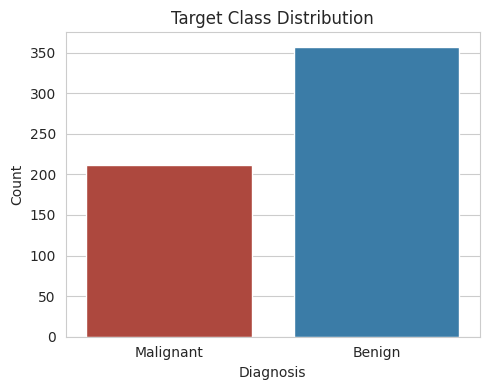

In [8]:
plt.figure(figsize=(5, 4))
sns.countplot(x=df["target"].map({0: "Malignant", 1: "Benign"}), palette=["#c0392b", "#2980b9"])
plt.title("Target Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


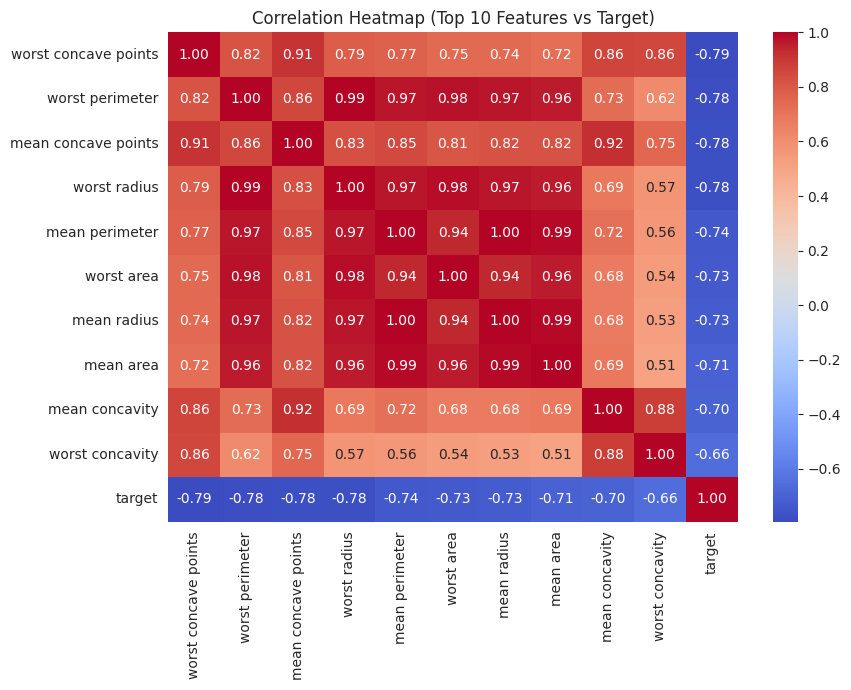

In [9]:
corr = df.corr()
top_corr_features = corr["target"].abs().sort_values(ascending=False).index[1:11]

plt.figure(figsize=(9, 7))
sns.heatmap(df[top_corr_features.tolist() + ["target"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Top 10 Features vs Target)")
plt.tight_layout()
plt.show()


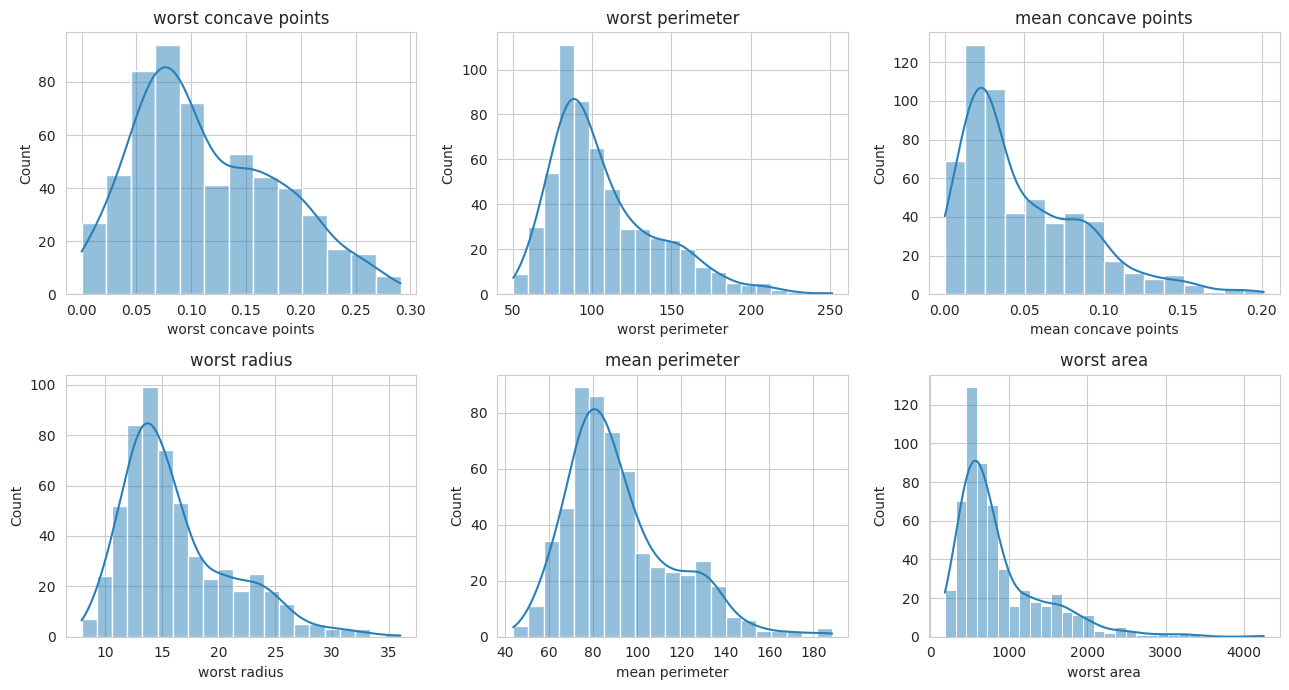

In [10]:
top6 = top_corr_features[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flatten(), top6):
    sns.histplot(df[col], kde=True, ax=ax, color="#2980b9")
    ax.set_title(col)
plt.tight_layout()
plt.show()


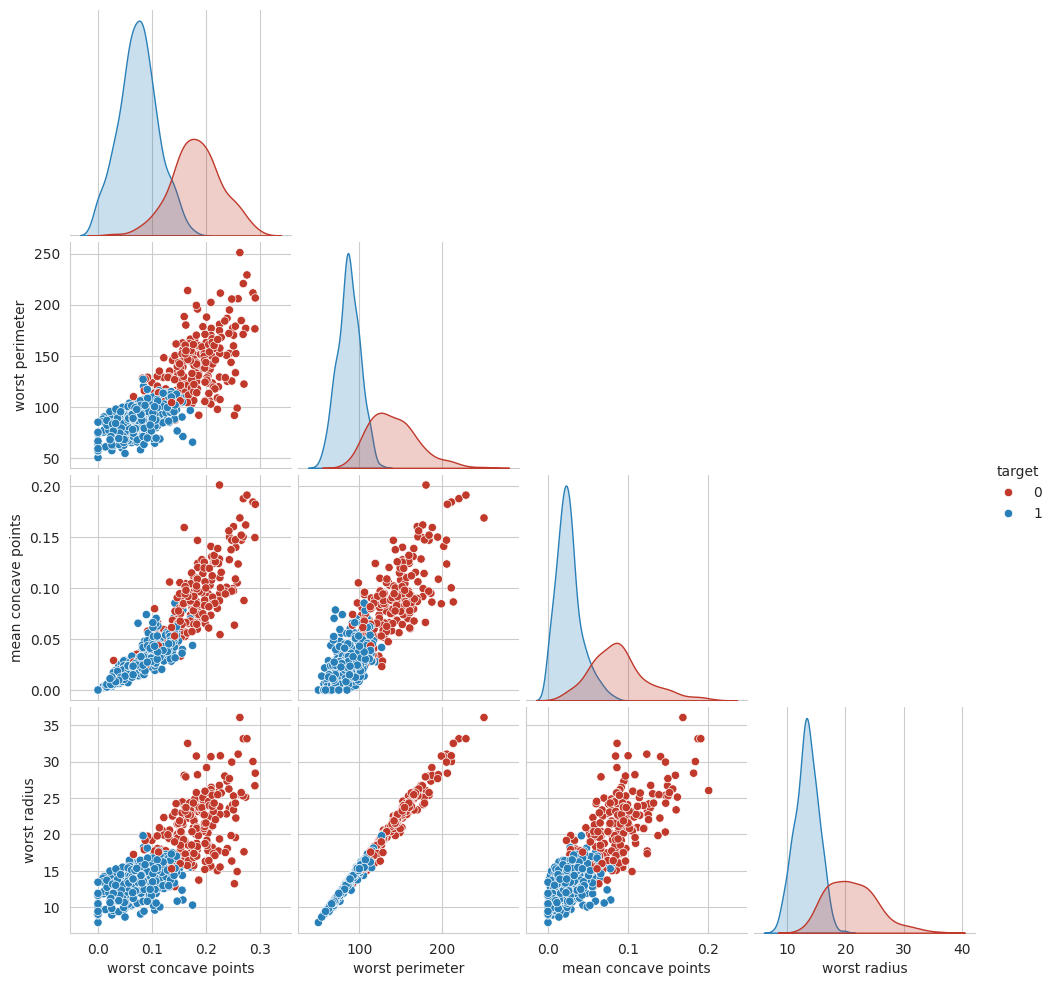

In [11]:
pair_cols = top_corr_features[:4].tolist() + ["target"]
sns.pairplot(df[pair_cols], hue="target", palette=["#c0392b", "#2980b9"], corner=True)
plt.show()


**Key EDA Observations:**

1. The dataset is moderately imbalanced with more benign (357) than malignant (212) cases, roughly a 63/37 split, mild enough that accuracy stays informative.
2. Features like *worst perimeter*, *worst radius*, and *worst concave points* correlate most strongly with diagnosis - tumor size/shape irregularity are strong cancer indicators.
3. Size-related features (radius, perimeter, area) are highly correlated with each other (multicollinearity), which tree-based models handle natively.
4. Histograms show right-skewed distributions for several "worst"/"mean" features - could benefit distance-based models (KNN, SVM) from further transformation.
5. No missing values were found; only a small number of statistical outliers were flagged, mostly in the malignant class where extreme tumor measurements are expected.


## Part 4: Model Building
Six supervised classification algorithms are trained: Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, and SVM.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
print("All models trained.")


All models trained.


## Part 5: Model Evaluation

In [13]:
metrics_table = []
roc_data = {}
conf_matrices = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    metrics_table.append({"Model": name, "Accuracy": acc, "Precision": prec,
                           "Recall": rec, "F1-Score": f1, "ROC-AUC": auc})
    conf_matrices[name] = cm
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

metrics_df = pd.DataFrame(metrics_table).sort_values("Accuracy", ascending=False).reset_index(drop=True)
metrics_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM,0.982456,0.986111,0.986111,0.986111,0.995040
2,KNN,0.973684,0.960000,1.000000,0.979592,0.988426
3,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993221
4,Naive Bayes,0.929825,0.944444,0.944444,0.944444,0.986772
5,Decision Tree,0.912281,0.955882,0.902778,0.928571,0.915675


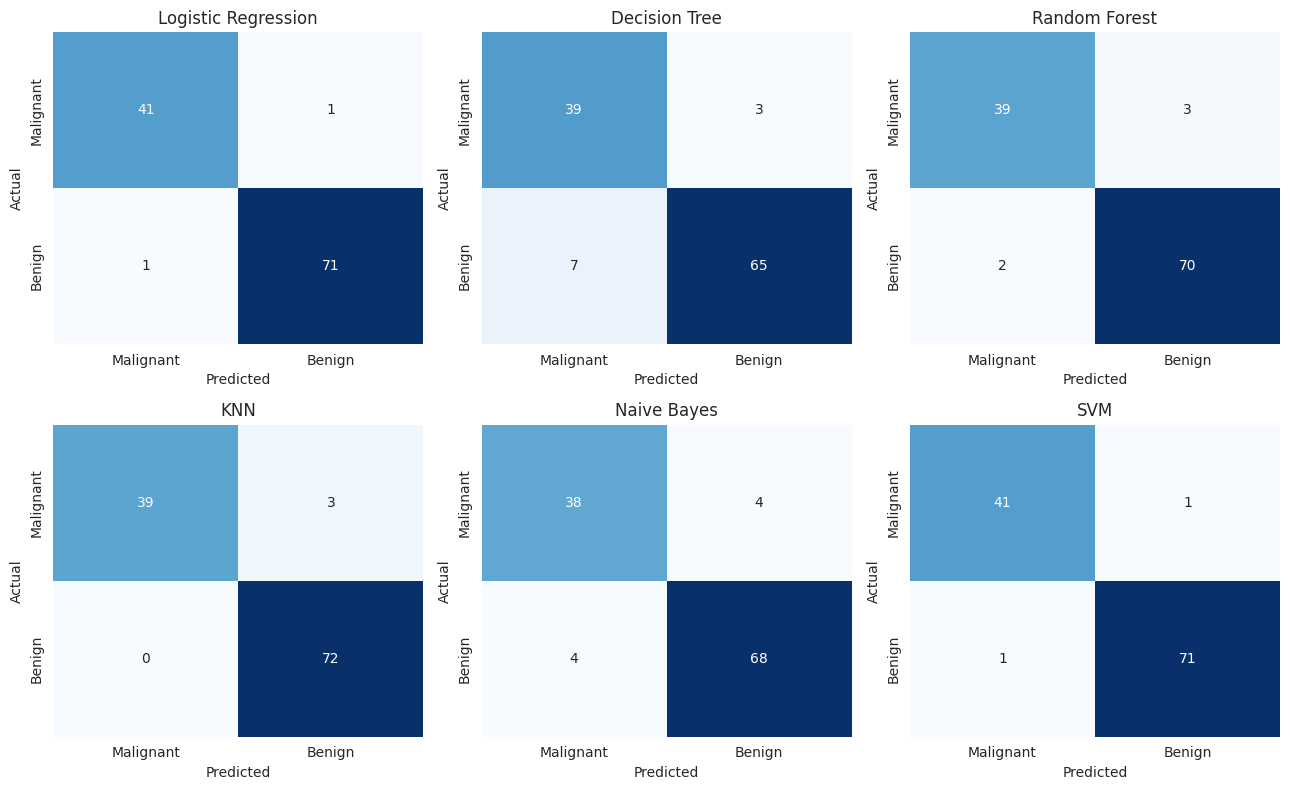

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (name, cm) in zip(axes.flatten(), conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


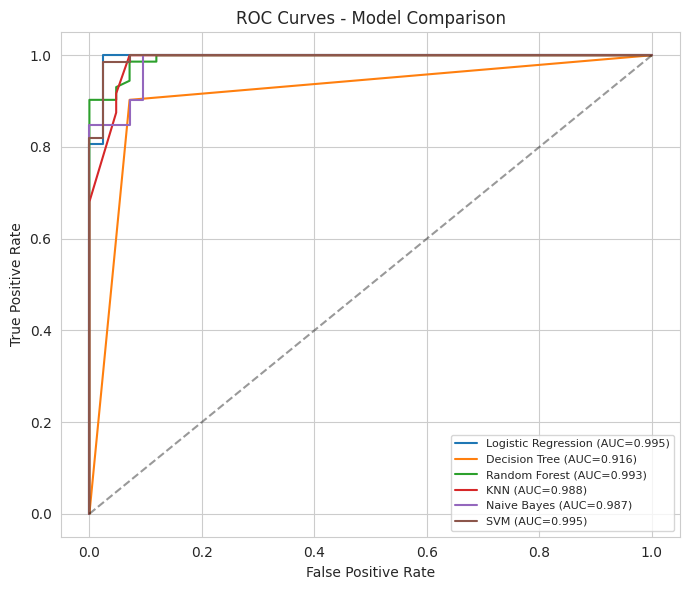

In [15]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


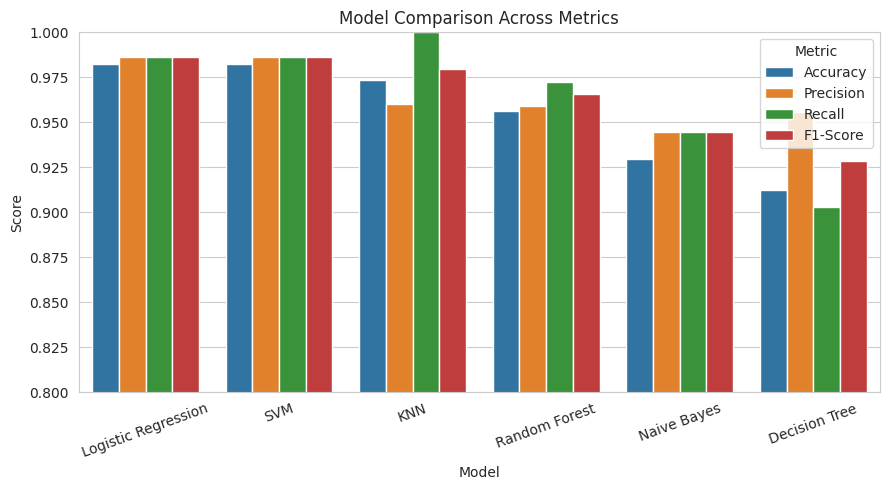

In [16]:
plot_df = metrics_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
                          var_name="Metric", value_name="Score")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.xticks(rotation=20)
plt.ylim(0.8, 1.0)
plt.title("Model Comparison Across Metrics")
plt.tight_layout()
plt.show()


In [17]:
best_model_name = metrics_df.iloc[0]["Model"]
print(f"Best performing model: {best_model_name}")
print(f"Accuracy: {metrics_df.iloc[0]['Accuracy']:.4f}")
print()
print("Classification Report for best model:")
print(classification_report(y_test, models[best_model_name].predict(X_test_scaled),
                             target_names=["Malignant", "Benign"]))


Best performing model: Logistic Regression
Accuracy: 0.9825

Classification Report for best model:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



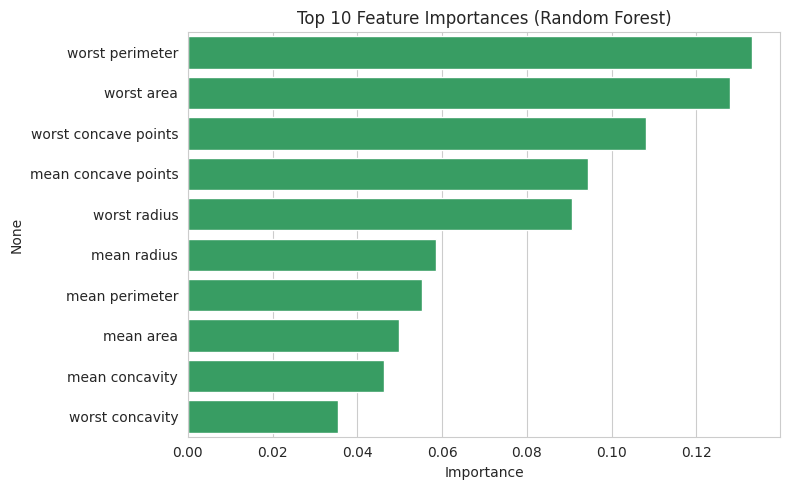

In [18]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, color="#27ae60")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Part 6: Conclusion

**Best Model:** Logistic Regression (and SVM, tied) achieved the highest accuracy (~98.2%) and ROC-AUC (~0.995) on the held-out test set.

**Justification:** After standard scaling, the classes in this dataset are close to linearly separable in the transformed feature space, which favors Logistic Regression and the RBF-kernel SVM. Both also had the best balance of precision and recall, minimizing costly false negatives (missed malignant cases).

**Challenges:**
- Multicollinearity among size-related features required scaling to keep linear/distance-based models stable.
- Mild class imbalance meant precision/recall/F1 needed to be considered alongside accuracy.
- Decision Tree alone overfit more than the ensemble (Random Forest), showing higher variance.

**Future Improvements:**
- Apply cross-validation and hyperparameter tuning (GridSearchCV/RandomizedSearchCV) for every model.
- Try feature selection or PCA to reduce redundancy among correlated features.
- Test additional resampling techniques (e.g., SMOTE) despite the mild imbalance, to check for further recall gains on the malignant class.
- Validate on an external/held-out dataset to confirm generalization.
